# SBI posterior parameter evaluation — transformer-reduced

Evaluates `exp_transformer-reduced_maf5_freeze-maf`: transformer encoder on 4 pressure waveforms + 5 scalar prefix tokens, 24-param theta (HR excluded).

**Point estimate comparison**: posterior mean vs GT — MAE, Median AE, MAPE  
**Posterior-specific**: 90% credible interval coverage per parameter

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path(globals()['_dh'][0])  # kernel cwd = ~/cv-sbi/
sys.path.insert(0, str(ROOT))

from dataset import ReducedCVDataset, PARAM_KEYS_INFER, load_stats
from train_sbi import TransformerWaveformEmbedding  # needed to unpickle the posterior

/home/sa4604/cv-sbi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUN_NAME       = 'exp_transformer-reduced_maf5_freeze-maf'
POSTERIOR_PATH = ROOT / f'outputs/{RUN_NAME}/posterior.pt'
STATS_PATH     = ROOT / 'norm_stats.json'
DATA_DIR       = Path('/media/pulsar/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/test')
MANIFEST       = DATA_DIR.parent / 'manifest_test.json'

BATCH_SIZE          = 256
BATCH_IDX           = 0
N_POSTERIOR_SAMPLES = 1000

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Load posterior and test data

In [3]:
posterior = torch.load(POSTERIOR_PATH, map_location=device, weights_only=False)
print('Posterior loaded:', type(posterior).__name__)

stats    = load_stats(STATS_PATH)
manifest = json.load(open(MANIFEST))

start   = BATCH_IDX * BATCH_SIZE
end     = start + BATCH_SIZE
entries = manifest['index'][start:end]
print(f'Test batch {BATCH_IDX}: sims {start}–{end - 1}  ({len(entries)} entries)')

ds     = ReducedCVDataset(str(DATA_DIR), entries, stats)
loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0)

all_theta, all_x = [], []
for theta_b, x_b in loader:
    all_theta.append(theta_b)
    all_x.append(x_b)
ds.close()

theta_gt = torch.cat(all_theta)  # (256, 24)
x_test   = torch.cat(all_x)      # (256, 809)
print(f'GT params: {theta_gt.shape}  observations: {x_test.shape}')

Posterior loaded: DirectPosterior
Test batch 0: sims 0–255  (256 entries)
GT params: torch.Size([256, 24])  observations: torch.Size([256, 809])


## Sample posterior for each test observation

In [4]:
all_means, all_q05, all_q95 = [], [], []

for i, x_o in enumerate(x_test):
    samples = posterior.sample((N_POSTERIOR_SAMPLES,), x=x_o.to(device), show_progress_bars=False)
    all_means.append(samples.mean(dim=0).cpu())
    all_q05.append(samples.quantile(0.05, dim=0).cpu())
    all_q95.append(samples.quantile(0.95, dim=0).cpu())
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(x_test)} done')

pred_mean = torch.stack(all_means).numpy()  # (256, 24)
q05       = torch.stack(all_q05).numpy()
q95       = torch.stack(all_q95).numpy()
gt_phys   = theta_gt.numpy()

print(f'Posterior mean shape: {pred_mean.shape}')

  50/256 done
  100/256 done
  150/256 done
  200/256 done
  250/256 done
Posterior mean shape: (256, 24)


In [5]:
# Diagnostics
emb_net = posterior.posterior_estimator.embedding_net

with torch.no_grad():
    emb_out = emb_net(x_test[:64].to(device))
print(f'Embedding output shape: {emb_out.shape}')
print(f'Per-dim std  min/mean/max: '
      f'{emb_out.std(0).min():.4f} / {emb_out.std(0).mean():.4f} / {emb_out.std(0).max():.4f}')
print(f'Overall mean: {emb_out.mean():.4f}  std: {emb_out.std():.4f}')

train_manifest = json.load(open(MANIFEST.parent / 'manifest_train.json'))
train_data_dir = '/media/pulsar/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/train'
ds_tr = ReducedCVDataset(train_data_dir, train_manifest['index'][:1], stats)
theta_tr, x_tr = ds_tr[0]
ds_tr.close()

with torch.no_grad():
    samples_tr = posterior.sample((500,), x=x_tr.to(device), show_progress_bars=False)
post_mean_tr = samples_tr.mean(0).cpu()

print(f"\nTraining obs sanity check:")
print(f"  {'param':<14} {'GT':>10} {'post mean':>12} {'err%':>8}")
for i, name in enumerate(PARAM_KEYS_INFER):
    err = abs(post_mean_tr[i].item() - theta_tr[i].item()) / (abs(theta_tr[i].item()) + 1e-9) * 100
    print(f"  {name:<14} {theta_tr[i].item():>10.4f} {post_mean_tr[i].item():>12.4f} {err:>7.1f}%")

Embedding output shape: torch.Size([64, 64])
Per-dim std  min/mean/max: 0.3948 / 0.9642 / 1.6514
Overall mean: 0.1053  std: 1.1357

Training obs sanity check:
  param                  GT    post mean     err%
  AVD              278.7117     185.7087    33.4%
  Bla                0.0598       0.0710    18.7%
  Blv                0.0211       0.0354    68.1%
  Bra                0.0664       0.0638     3.9%
  Brv                0.0511       0.0431    15.7%
  Cas                0.7144       0.7270     1.8%
  Cvp                5.2836       6.3049    19.3%
  Cvs               50.4620      80.5102    59.5%
  Eap                3.0521       3.0811     1.0%
  Eedref_la          2.0508       1.2579    38.7%
  Eedref_lv          0.7180       1.1452    59.5%
  Eedref_ra          0.3933       0.7116    80.9%
  Eedref_rv          0.5214       0.3478    33.3%
  Emax_LA            0.5651       0.4400    22.1%
  Emax_LV            4.9090       2.1113    57.0%
  Emax_RA            0.1293       0.4114 

## Point-estimate metrics

In [6]:
abs_err = np.abs(pred_mean - gt_phys)
ch_mae  = abs_err.mean(axis=0)
ch_med  = np.median(abs_err, axis=0)
ch_mape = (abs_err / (np.abs(gt_phys) + 1e-9) * 100).mean(axis=0)

print(f"{'Parameter':<14} {'MAE':>12} {'Median AE':>12} {'MAPE (%)':>10}")
print('-' * 52)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f'{name:<14} {ch_mae[i]:>12.4f} {ch_med[i]:>12.4f} {ch_mape[i]:>10.2f}%')

print(f'\nOverall  MAE (mean): {ch_mae.mean():.4f}  MAPE: {ch_mape.mean():.2f}%')

Parameter               MAE    Median AE   MAPE (%)
----------------------------------------------------
AVD                 51.4478      48.4781      35.68%
Bla                  0.0217       0.0220      41.78%
Blv                  0.0095       0.0093      29.68%
Bra                  0.0171       0.0170      34.65%
Brv                  0.0083       0.0076      24.05%
Cas                  0.0232       0.0144       1.86%
Cvp                  1.1492       0.8139      31.49%
Cvs                 20.9928      20.5640      36.61%
Eap                  0.1295       0.0122       7.99%
Eedref_la            0.5317       0.5002     111.29%
Eedref_lv            0.4040       0.3789     111.96%
Eedref_ra            0.2454       0.1896     104.88%
Eedref_rv            0.2130       0.1503      64.83%
Emax_LA              0.1500       0.1341      44.35%
Emax_LV              0.7303       0.5295      36.34%
Emax_RA              0.1400       0.1170      47.10%
Emax_RV              0.2284       0.1265      1

In [7]:
post_mean_std = pred_mean.std(axis=0)
prior_range   = np.array([
    manifest['config']['pvar_high'][k] - manifest['config']['pvar_low'][k]
    for k in PARAM_KEYS_INFER
])
variation_pct = post_mean_std / prior_range * 100

print(f"{'param':<14} {'post-mean std':>14} {'prior range':>12} {'variation %':>12}")
print('-' * 55)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f"{name:<14} {post_mean_std[i]:>14.4f} {prior_range[i]:>12.4f} {variation_pct[i]:>11.1f}%")

print(f"\nMean variation across params: {variation_pct.mean():.1f}% of prior range")

param           post-mean std  prior range  variation %
-------------------------------------------------------
AVD                   35.2907     240.0000        14.7%
Bla                    0.0068       0.0900         7.5%
Blv                    0.0027       0.0400         6.7%
Bra                    0.0059       0.0700         8.5%
Brv                    0.0050       0.0400        12.6%
Cas                    0.7136       2.4500        29.1%
Cvp                    1.5808       8.0000        19.8%
Cvs                    5.6454      90.0000         6.3%
Eap                    1.4070       4.9700        28.3%
Eedref_la              0.3282       2.4000        13.7%
Eedref_lv              0.2812       1.9200        14.6%
Eedref_ra              0.2979       1.4700        20.3%
Eedref_rv              0.3337       1.4700        22.7%
Emax_LA                0.1743       0.9000        19.4%
Emax_LV                0.8914       4.5000        19.8%
Emax_RA                0.1092       0.7000      

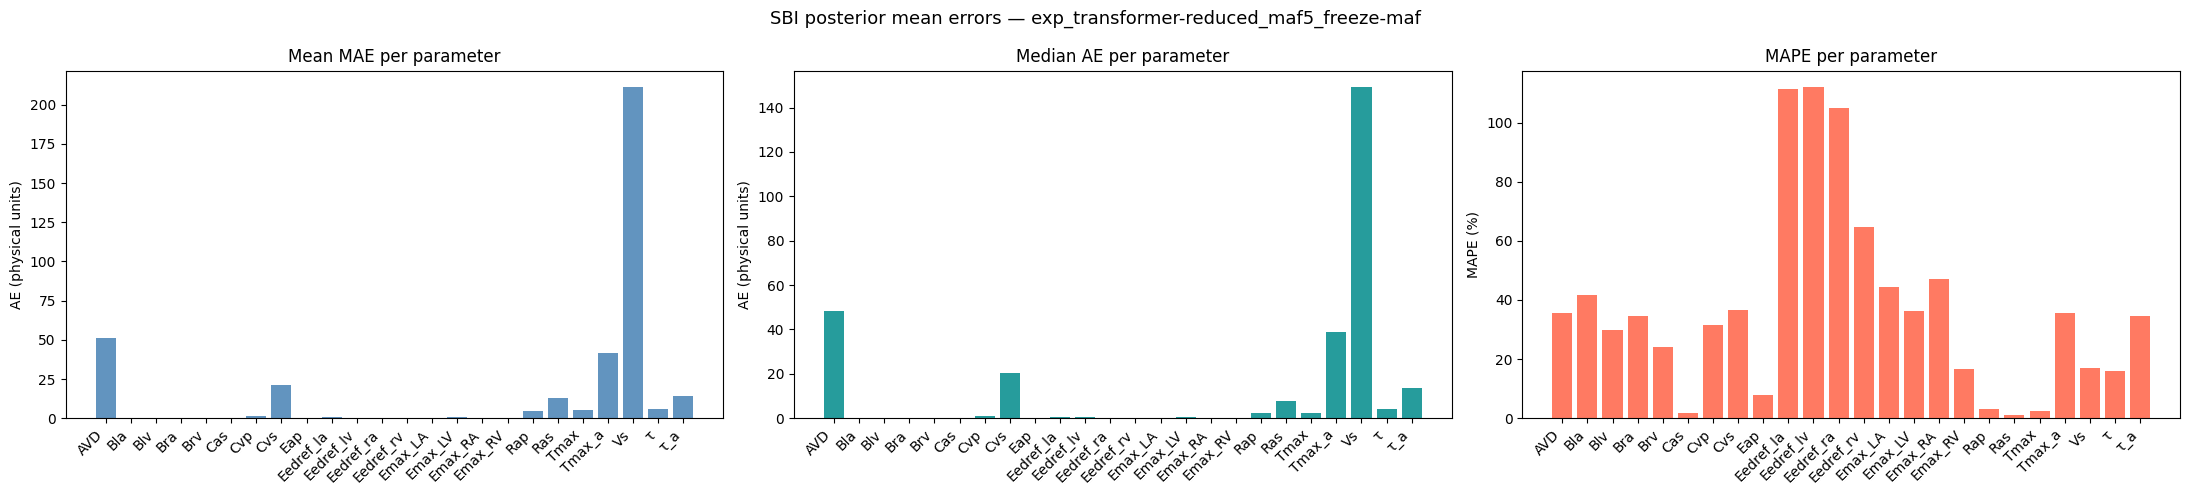

In [8]:
x_pos = np.arange(len(PARAM_KEYS_INFER))
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].bar(x_pos, ch_mae,  color='steelblue', alpha=0.85)
axes[1].bar(x_pos, ch_med,  color='darkcyan',  alpha=0.85)
axes[2].bar(x_pos, ch_mape, color='tomato',    alpha=0.85)

for ax, title, ylabel in zip(axes,
    ['Mean MAE per parameter', 'Median AE per parameter', 'MAPE per parameter'],
    ['AE (physical units)', 'AE (physical units)', 'MAPE (%)']):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f'SBI posterior mean errors — {RUN_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

## Predicted vs GT scatter — 24 parameters

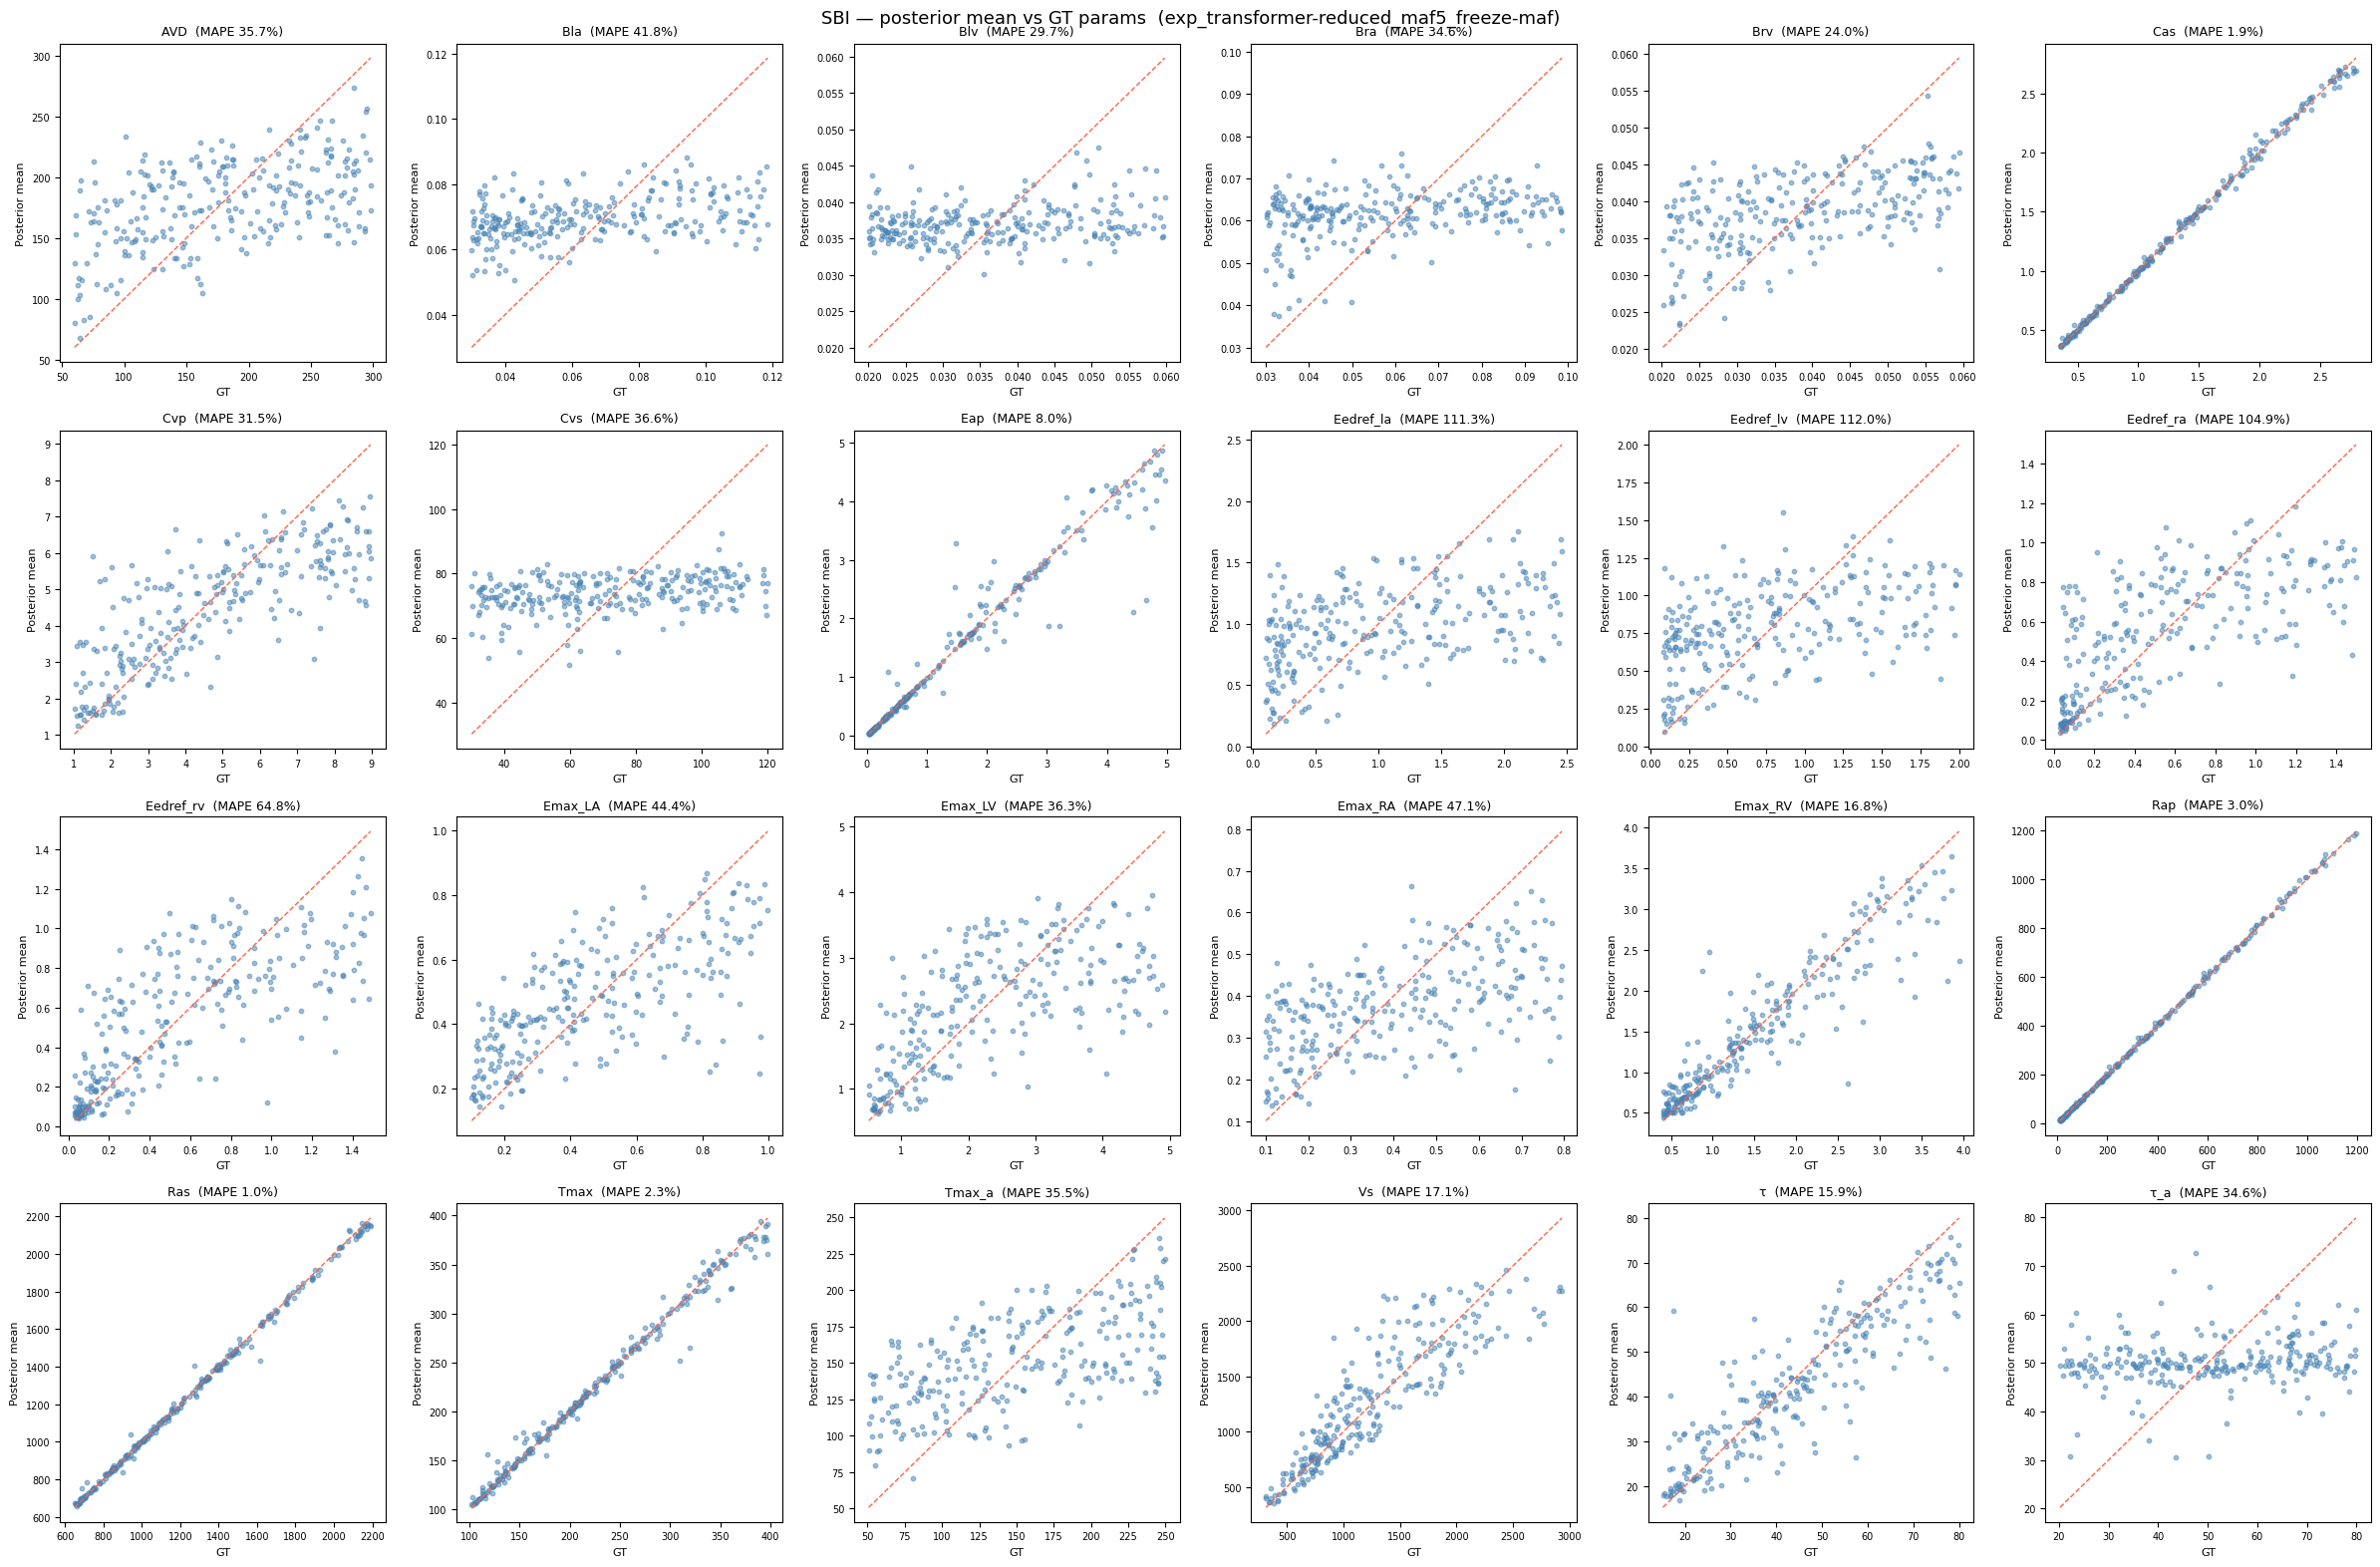

In [9]:
ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    gt_i, pred_i = gt_phys[:, i], pred_mean[:, i]
    lo, hi = gt_i.min(), gt_i.max()
    ax.scatter(gt_i, pred_i, s=10, alpha=0.5, color='steelblue')
    ax.plot([lo, hi], [lo, hi], color='tomato', linewidth=1, linestyle='--')
    ax.set_title(f'{name}  (MAPE {ch_mape[i]:.1f}%)', fontsize=9)
    ax.set_xlabel('GT', fontsize=8)
    ax.set_ylabel('Posterior mean', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(f'SBI — posterior mean vs GT params  ({RUN_NAME})', fontsize=13)
plt.tight_layout()
plt.show()

## 90% credible interval coverage

For a well-calibrated posterior, ~90% of GT values should fall inside the 90% CI.

In [10]:
in_ci    = (gt_phys >= q05) & (gt_phys <= q95)
coverage = in_ci.mean(axis=0) * 100

print(f"{'Parameter':<14} {'90% CI coverage':>18}")
print('-' * 35)
for i, name in enumerate(PARAM_KEYS_INFER):
    flag = '  ✓' if 85 <= coverage[i] <= 95 else '  ←'
    print(f'{name:<14} {coverage[i]:>16.1f}%{flag}')

print(f'\nMean coverage: {coverage.mean():.1f}%  (target: 90%)')

Parameter         90% CI coverage
-----------------------------------
AVD                        76.2%  ←
Bla                        75.4%  ←
Blv                        77.0%  ←
Bra                        78.5%  ←
Brv                        82.8%  ←
Cas                        90.6%  ✓
Cvp                        84.0%  ←
Cvs                        80.9%  ←
Eap                        91.8%  ✓
Eedref_la                  83.2%  ←
Eedref_lv                  85.2%  ✓
Eedref_ra                  82.8%  ←
Eedref_rv                  82.8%  ←
Emax_LA                    86.3%  ✓
Emax_LV                    84.8%  ←
Emax_RA                    80.9%  ←
Emax_RV                    85.9%  ✓
Rap                        94.9%  ✓
Ras                        89.8%  ✓
Tmax                       88.3%  ✓
Tmax_a                     77.7%  ←
Vs                         80.1%  ←
τ                          81.2%  ←
τ_a                        79.7%  ←

Mean coverage: 83.4%  (target: 90%)


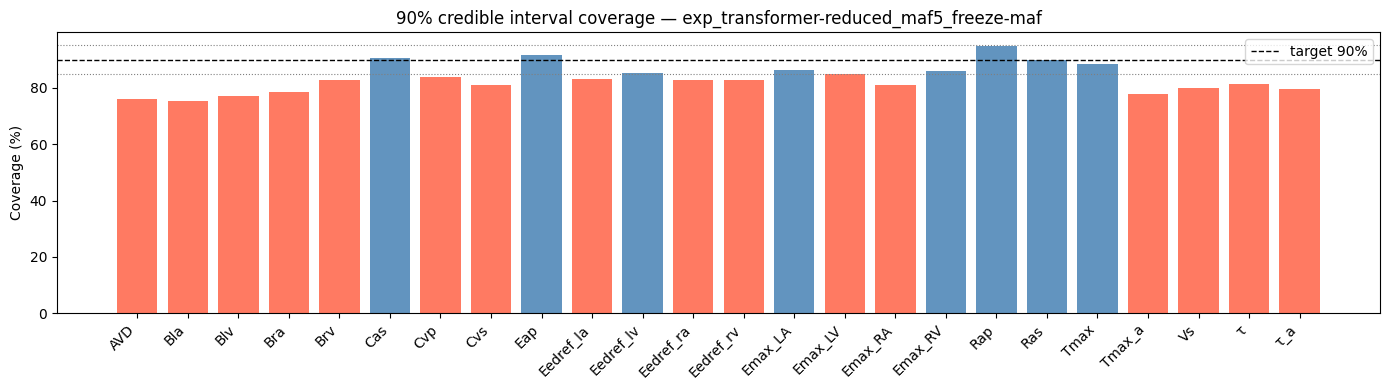

In [11]:
x_pos  = np.arange(len(PARAM_KEYS_INFER))
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if 85 <= c <= 95 else 'tomato' for c in coverage]
ax.bar(x_pos, coverage, color=colors, alpha=0.85)
ax.axhline(90, color='black', linestyle='--', linewidth=1, label='target 90%')
ax.axhline(85, color='gray',  linestyle=':',  linewidth=0.8)
ax.axhline(95, color='gray',  linestyle=':',  linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
ax.set_ylabel('Coverage (%)')
ax.set_title(f'90% credible interval coverage — {RUN_NAME}')
ax.legend()
plt.tight_layout()
plt.show()